# Cardiac Patient Monitoring System
## 03 — EDA, Statistics & Visualization (Phase 3, Milestone M2)

Input: `data/processed/heart_disease_cleveland_stage2.csv` (Phase 2 checkpoint — values unchanged,
cleaning decisions documented, no imputation/encoding/scaling applied yet).

This notebook covers:
1. Descriptive statistics (mean, median, std, IQR)
2. Distribution analysis — numerical features (histograms, boxplots)
3. Categorical analysis — countplots
4. Target class balance (counts + proportions)
5. Correlation analysis (heatmap)
6. Outlier analysis (visual, tied to Phase 2 IQR screening)
7. Bivariate analysis — features vs target
8. EDA findings summary

Every chart is followed by a short interpretation — no decorative or repetitive plots.
Correlation is discussed as association, not causation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', 20)
sns.set_style("whitegrid")
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/processed/heart_disease_cleveland_stage2.csv")

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

df.shape


(303, 15)

## 1. Descriptive statistics — numerical features


In [2]:
desc = df[numerical_features].describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc


,count,mean,std,min,25%,50%,75%,max,IQR
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0,13.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0,20.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0,64.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0,32.5
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2,1.6


**Interpretation:**
- `age`: mean ~54, roughly symmetric, range 29–77 — a broad adult-to-senior population.
- `trestbps` (resting BP): mean ~132 mm Hg, IQR ~20 — mild right-skew expected (a few hypertensive
  outliers, consistent with the Phase 2 IQR screening).
- `chol`: mean ~247 mg/dl, largest spread (std ~52) and widest max (564) — the most skewed
  numerical feature.
- `thalach` (max heart rate): mean ~150, fairly symmetric, widest usable spread — likely a strong
  discriminating feature since max HR naturally declines with cardiac impairment.
- `oldpeak`: heavily right-skewed — median 0.8 vs mean 1.04, with many patients at 0.0 (no ST
  depression) and a long tail up to 6.2.


## 2. Distribution analysis — numerical features (histograms)


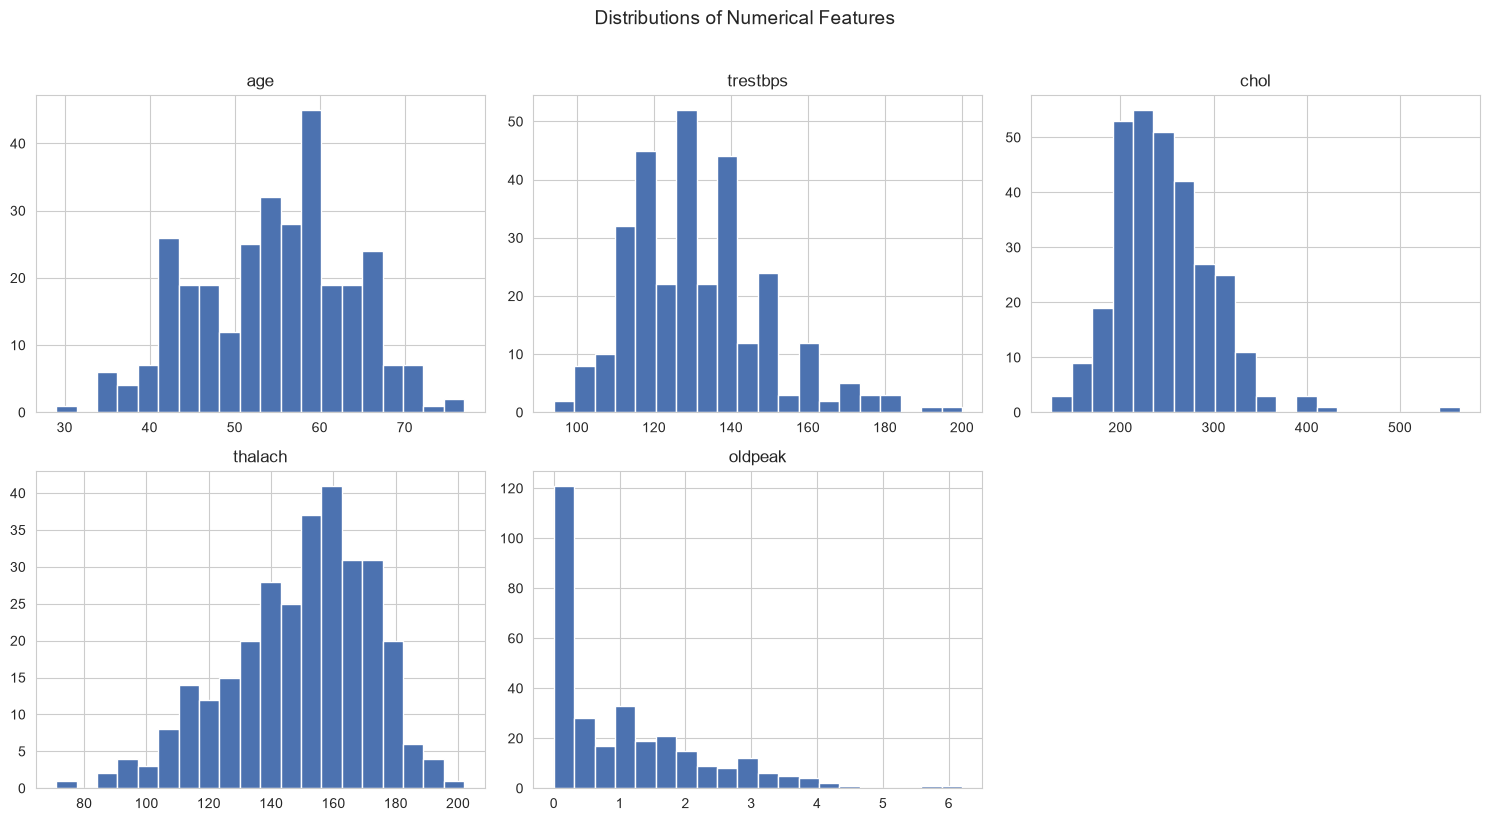

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=20, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle("Distributions of Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_numerical_histograms.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** `age` and `thalach` are approximately symmetric/bell-shaped. `chol` and
`trestbps` show mild-to-moderate right skew with a longer tail toward high values. `oldpeak` is
strongly right-skewed with a large mass at 0 — expected, since many patients show no exercise-
induced ST depression at all. This skew motivates using median-based summaries (already used
above) and, later, scaling that is robust to outliers for the linear baseline model.


## 3. Distribution analysis — boxplots (outlier visualization)


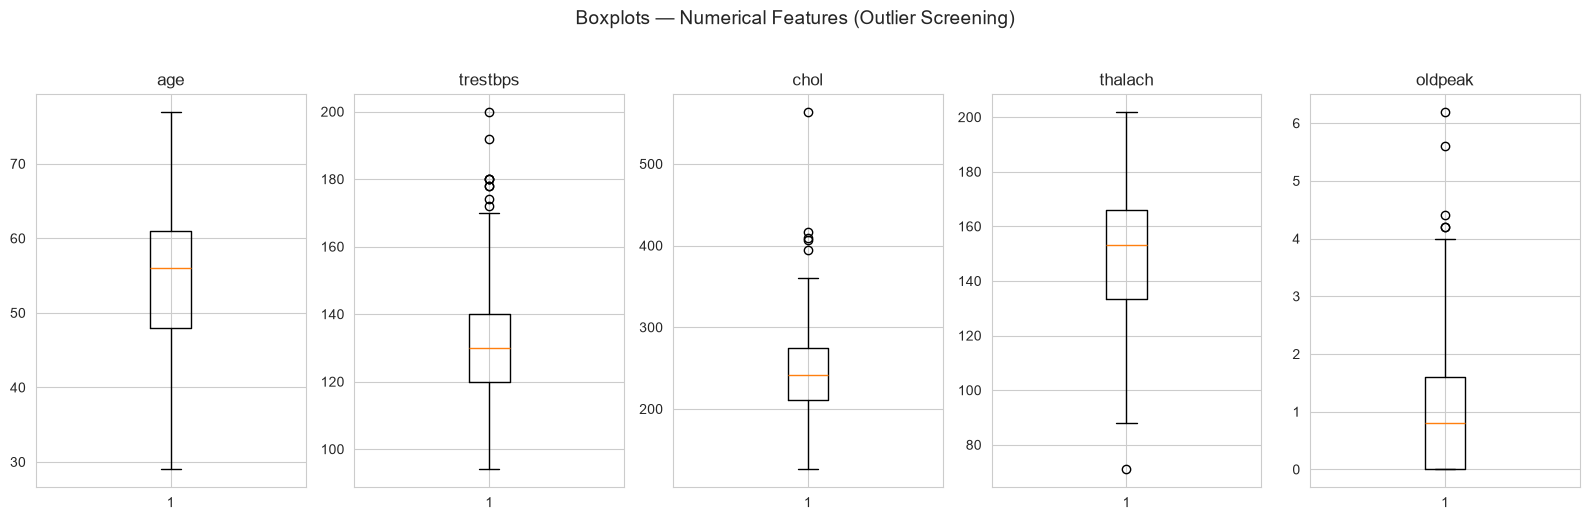

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for i, col in enumerate(numerical_features):
    axes[i].boxplot(df[col].dropna(), orientation='vertical')
    axes[i].set_title(col)
plt.suptitle("Boxplots — Numerical Features (Outlier Screening)", y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numerical_boxplots.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** Consistent with the Phase 2 IQR counts, `trestbps`, `chol`, and `oldpeak`
show visible high-side outlier points. These are treated as legitimate rare clinical
observations (e.g. patients with unusually high cholesterol or blood pressure), not
data-entry errors, and are not removed — consistent with the project's non-destructive
outlier-handling rule.


## 4. Categorical analysis — countplots


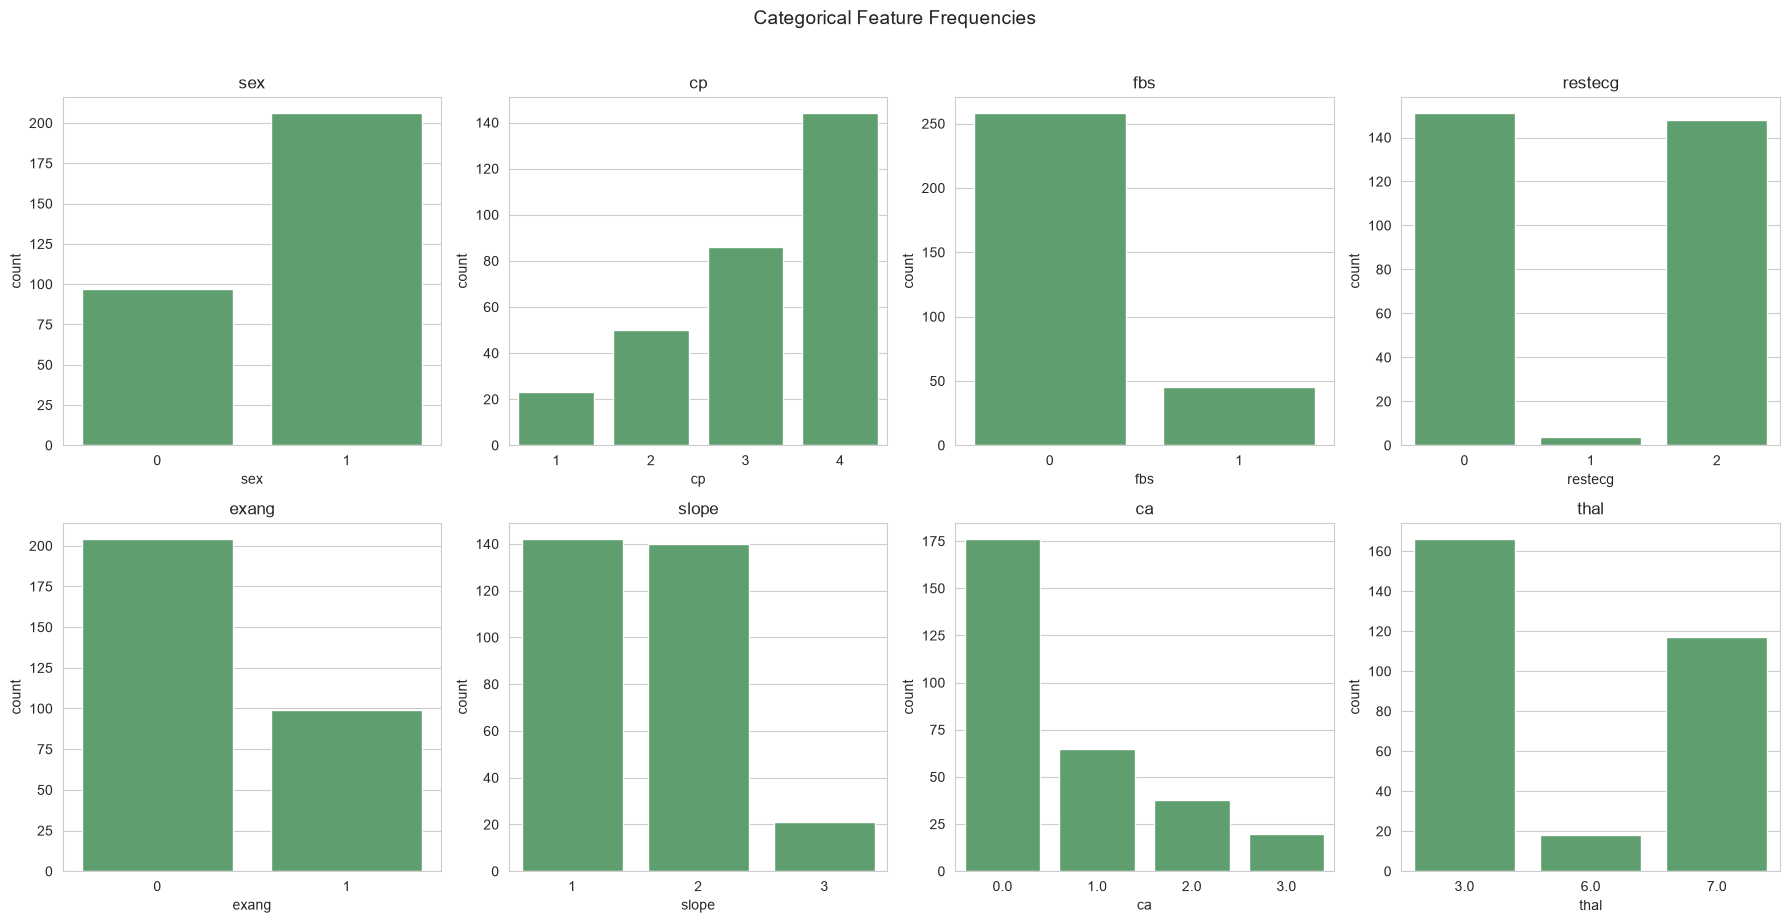

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    order = sorted(df[col].dropna().unique())
    sns.countplot(x=df[col], order=order, ax=axes[i], color='#55A868')
    axes[i].set_title(col)
plt.suptitle("Categorical Feature Frequencies", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_categorical_countplots.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** `sex` is imbalanced (~68% male), reflecting the original clinical
sampling, not a data issue — worth noting as a limitation later. `cp` (chest pain type) is
dominated by category 4 (asymptomatic) and 3 (non-anginal). `restecg` category 1 is rare relative
to 0 and 2. `thal` category 6 is rare relative to 3 and 7. These rare categories are kept (not
merged or dropped) since one-hot encoding in the Pipeline (Phase 6) will handle them safely, but
we flag them as candidates for review if a model shows instability on those levels.


## 5. Target class balance


In [6]:
counts = df[target_col].value_counts().sort_index()
props = df[target_col].value_counts(normalize=True).sort_index().round(3)
pd.DataFrame({'count': counts, 'proportion': props}).rename(
    index={0: 'absence (0)', 1: 'presence (1)'}
)


,count,proportion
target,,
absence (0),164,0.541
presence (1),139,0.459


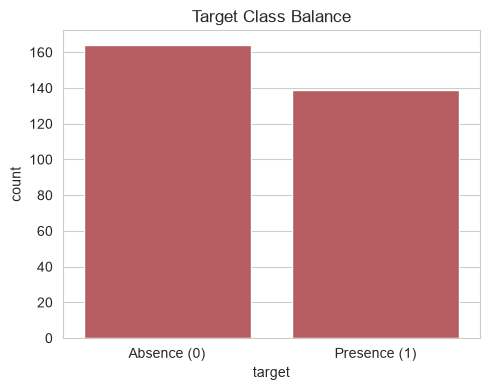

In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df[target_col], color='#C44E52')
plt.xticks([0, 1], ['Absence (0)', 'Presence (1)'])
plt.title("Target Class Balance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_target_balance.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** 164 vs 139 (~54% / 46%) — close to balanced. This means accuracy alone
would already be a reasonably meaningful metric here (unlike heavily imbalanced medical datasets),
but we still prioritize recall/F1/ROC-AUC in Phase 5 for the domain-appropriate reason that missing
a true positive (a patient with disease) is more costly than a false alarm. Stratified
train/test split and stratified k-fold CV will preserve this ~54/46 ratio throughout.


## 6. Correlation analysis (numerical features + target)


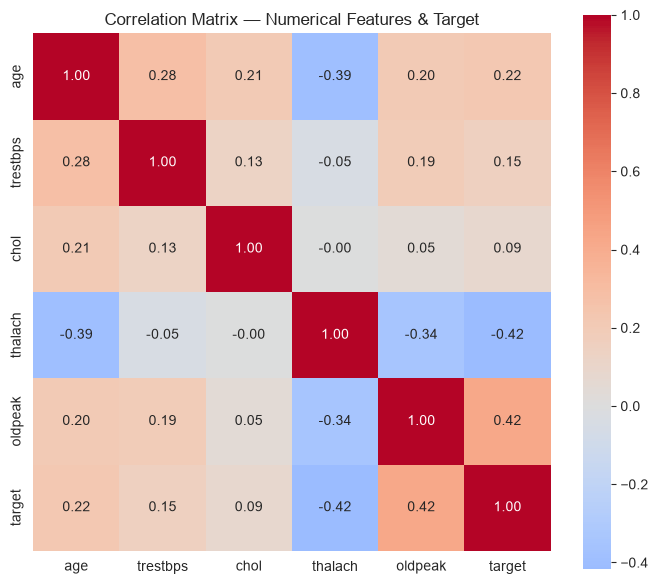

In [8]:
corr_cols = numerical_features + [target_col]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Numerical Features & Target")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_correlation_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation (association, not causation):**
- `thalach` (max heart rate) is **negatively** correlated with `target` — lower max heart rate is
  associated with higher likelihood of disease presence, consistent with known cardiac physiology
  (reduced exercise capacity).
- `oldpeak` is **positively** correlated with `target` — larger ST depression is associated with
  disease presence.
- `age` and `trestbps`/`chol` show weaker positive correlations with the target than `thalach`/
  `oldpeak`, suggesting the categorical features (`cp`, `ca`, `thal`, `exang`) may carry more
  discriminative signal — checked next.
- No numerical feature pair shows extreme multicollinearity (|r| > 0.7), so no feature needs to be
  dropped purely for redundancy.


## 7. Bivariate analysis — key categorical features vs target


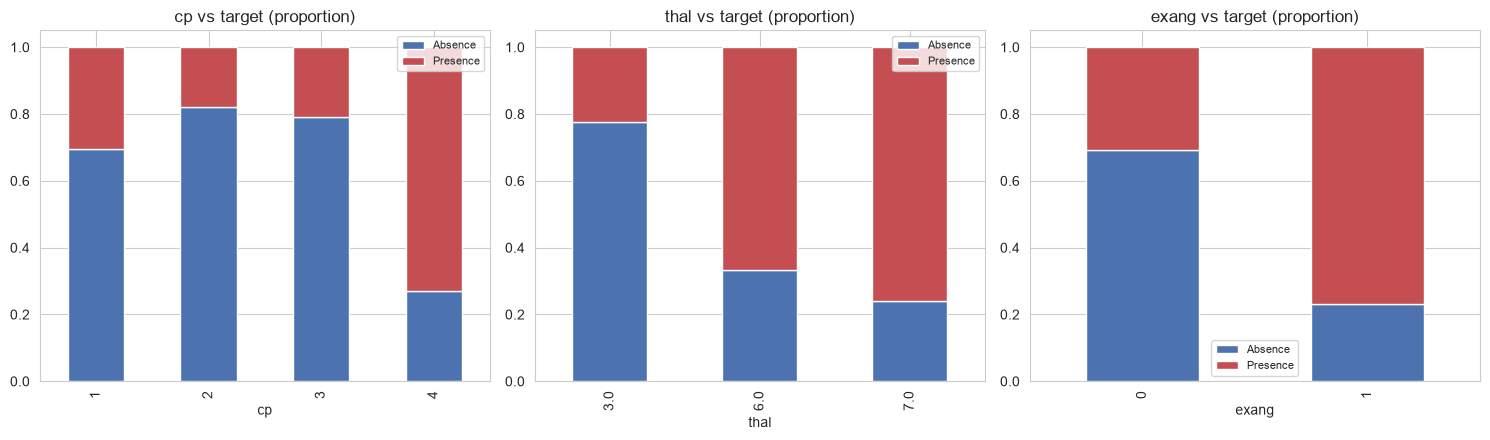

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['cp', 'thal', 'exang']):
    ct = pd.crosstab(df[col], df[target_col], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
    ax.set_title(f"{col} vs target (proportion)")
    ax.legend(['Absence', 'Presence'], fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_categorical_vs_target.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** `cp` category 4 (asymptomatic chest pain) shows a markedly higher
proportion of disease presence than categories 1–3 — counter-intuitive at first glance, but
clinically known: asymptomatic patients in this dataset were often referred for angiography due to
other risk indicators. `thal` category 7 (reversible defect) and `exang` = 1 (exercise-induced
angina present) both show a clearly higher proportion of disease presence. These three features
look like strong candidates for driving model performance and will be worth inspecting via feature
importance in Phase 5.


## 8. Numerical feature distributions split by target


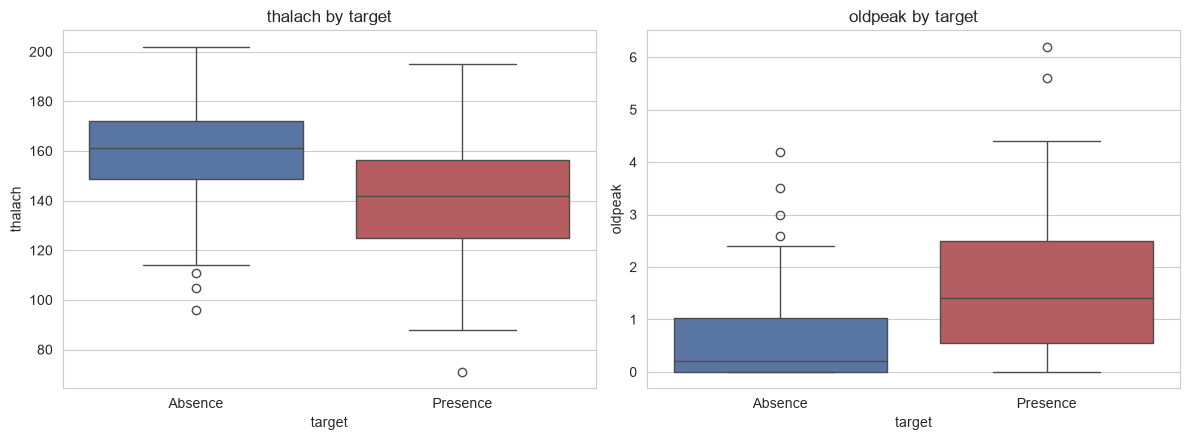

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col in zip(axes, ['thalach', 'oldpeak']):
    sns.boxplot(x=target_col, y=col, data=df, ax=ax, hue=target_col, palette=['#4C72B0', '#C44E52'], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Absence', 'Presence'])
    ax.set_title(f"{col} by target")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_numerical_by_target.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** Patients with disease presence show a visibly lower median `thalach` and
a visibly higher median `oldpeak` than patients without disease, with limited overlap in the
interquartile ranges — reinforcing the correlation findings above and suggesting both features
will contribute real separating power to the classifiers in Phase 4–5.


## 9. EDA Findings Summary

- **Class balance:** ~54% absence / 46% presence — near-balanced, stratified splitting/CV is
  sufficient (no resampling needed).
- **Strongest numerical signals:** `thalach` (negative association with disease) and `oldpeak`
  (positive association with disease).
- **Strongest categorical signals:** `cp` (esp. category 4), `thal` (esp. category 7), `exang`.
- **Skew:** `chol`, `trestbps`, `oldpeak` are right-skewed with legitimate high-end outliers —
  kept, to be handled via scaling (not removal) for the linear baseline.
- **No severe multicollinearity** among numerical features — no feature dropped at this stage.
- **Class imbalance in `sex`** (~68% male) noted as a demographic limitation of the source data,
  not a modeling defect — to be restated in the Phase 8 limitations section.

**Next:** Phase 4 — Supervised Learning Baseline (train/test split + Logistic Regression),
Milestone M3.
